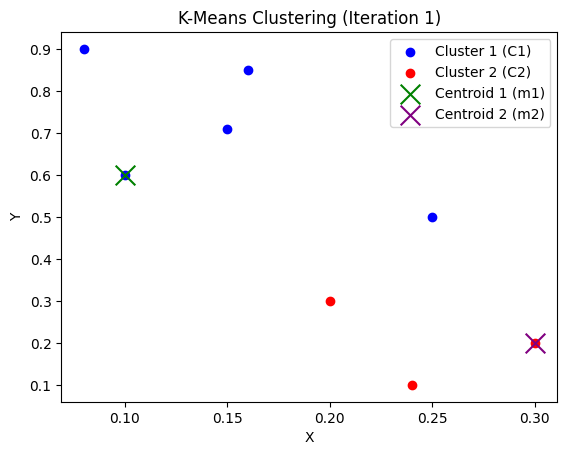

1. P6 belongs to Cluster #1
2. Population of Cluster 2 (C2) around m2: 3
3. Updated centroid m1: [0.148 0.712]
3. Updated centroid m2: [0.24666667 0.2       ]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Points given in the problem
points = {
    'P1': [0.1, 0.6],
    'P2': [0.15, 0.71],
    'P3': [0.08, 0.9],
    'P4': [0.16, 0.85],
    'P5': [0.2, 0.3],
    'P6': [0.25, 0.5],
    'P7': [0.24, 0.1],
    'P8': [0.3, 0.2]
}

# Convert points into a dataframe for easier handling
df = pd.DataFrame(points).T
df.columns = ['x', 'y']

# Initial centroids
m1 = np.array([0.1, 0.6])  # P1
m2 = np.array([0.3, 0.2])  # P8

# Function to calculate Euclidean distance
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# Function to assign points to the nearest centroid
def assign_clusters(df, m1, m2):
    clusters = []
    for index, row in df.iterrows():
        dist_to_m1 = euclidean_distance(row.values, m1)
        dist_to_m2 = euclidean_distance(row.values, m2)
        if dist_to_m1 < dist_to_m2:
            clusters.append(1)  # Assign to Cluster 1
        else:
            clusters.append(2)  # Assign to Cluster 2
    return clusters

# Function to update the centroids
def update_centroid(df, cluster_num):
    cluster_points = df[df['Cluster'] == cluster_num]
    return np.mean(cluster_points[['x', 'y']], axis=0).values

# Running the K-Means algorithm for one iteration
df['Cluster'] = assign_clusters(df, m1, m2)

# Calculate updated centroids
m1_updated = update_centroid(df, 1)
m2_updated = update_centroid(df, 2)

# Answering the questions:
# 1. Which cluster does P6 belong to?
cluster_p6 = df.loc['P6', 'Cluster']

# 2. What is the population of the cluster around m2?
population_cluster_around_m2 = df[df['Cluster'] == 2].shape[0]

# Plotting the points and the clusters
plt.scatter(df[df['Cluster'] == 1]['x'], df[df['Cluster'] == 1]['y'], color='blue', label='Cluster 1 (C1)')
plt.scatter(df[df['Cluster'] == 2]['x'], df[df['Cluster'] == 2]['y'], color='red', label='Cluster 2 (C2)')
plt.scatter(m1[0], m1[1], color='green', s=200, marker='x', label='Centroid 1 (m1)')
plt.scatter(m2[0], m2[1], color='purple', s=200, marker='x', label='Centroid 2 (m2)')
plt.title('K-Means Clustering (Iteration 1)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

# Printing the results
print(f"1. P6 belongs to Cluster #{cluster_p6}")
print(f"2. Population of Cluster 2 (C2) around m2: {population_cluster_around_m2}")
print(f"3. Updated centroid m1: {m1_updated}")
print(f"3. Updated centroid m2: {m2_updated}")